## NumPy的应用-2

### 数组对象的方法

#### 获取描述统计信息

描述统计信息主要包括数据的集中趋势、离散程度和频数分析等，其中集中趋势主要看均值和中位数，离散程度可以看极值、方差、标准差等，详细的内容大家可以阅读[《统计思维系列课程01：解读数据》](https://zhuanlan.zhihu.com/p/595273755)。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
array1 = np.random.randint(1, 100, 10)
array1

array([84, 28, 92, 28, 17, 82, 56,  6, 11, 40])

**计算总和、均值和中位数。**

代码：

In [3]:
print(array1.sum())
print(np.sum(array1))
print(array1.mean())
print(np.mean(array1))
print(np.median(array1))
print(np.quantile(array1, 0.5))

444
444
44.4
44.4
34.0
34.0


> **说明**：上面代码中的`mean`、`median`和`quantile`分别是 NumPy 中计算算术平均值、中位数和分位数的函数，其中`quantitle`函数的第二个参数设置为0.5表示计算50%分位数，也就是中位数。

**极值、全距和四分位距离。**

代码：

In [4]:
print(array1.max())
print(np.amax(array1))
print(array1.min())
print(np.amin(array1))
print(np.ptp(array1))
print(np.ptp(array1))
q1, q3 = np.quantile(array1, [0.25, 0.75])
print(q3 - q1)

92
92
6
6
86
86
55.75


**方差、标准差和变异系数。**

代码：

In [5]:
print(array1.var())
print(np.var(array1))
print(array1.std())
print(np.std(array1))
print(array1.std() / array1.mean())

928.04
928.04
30.463748948545383
30.463748948545383
0.6861204718140852


**绘制箱线图。**

箱线图又称为盒须图，是显示一组数据分散情况的统计图，因形状如箱子而得名。 它主要用于反映原始数据分布的特征，还可以进行多组数据分布特征的比较。

代码：

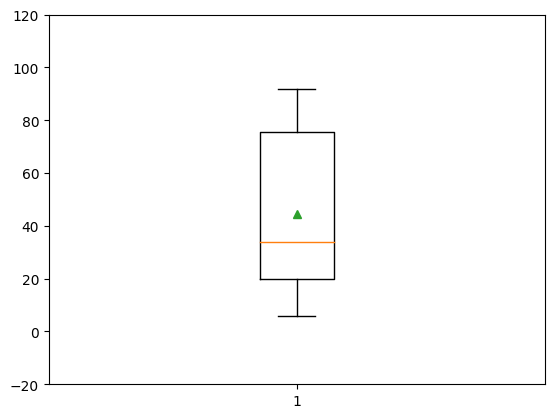

In [6]:
plt.boxplot(array1, showmeans=True)
plt.ylim([-20, 120])
plt.show()

值得注意的是，对于二维或更高维的数组，在获取描述统计信息时，可以通过名为`axis`的参数指定均值、方差等运算是沿着哪一个轴来执行，`axis`参数不同，执行的结果可能是大相径庭的，如下所示。

代码：

In [7]:
array2 = np.random.randint(60, 101, (5, 3))
array2

array([[ 67,  97,  60],
       [ 74,  74,  85],
       [ 68,  90,  65],
       [100,  89,  65],
       [ 74,  81, 100]])

代码：

In [8]:
array2.mean()

79.26666666666667

代码：

In [9]:
array2.mean(axis=0)

array([76.6, 86.2, 75. ])

代码：

In [10]:
array2.mean(axis=1)

array([74.66666667, 77.66666667, 74.33333333, 84.66666667, 85.        ])

代码：

In [11]:
array2.max(axis=0)

array([100,  97, 100])

代码：

In [12]:
array2.max(axis=1)

array([ 97,  85,  90, 100, 100])

再看看绘制箱线图，对于二维数组每一列都会产生一个统计图形，如下所示。

代码：

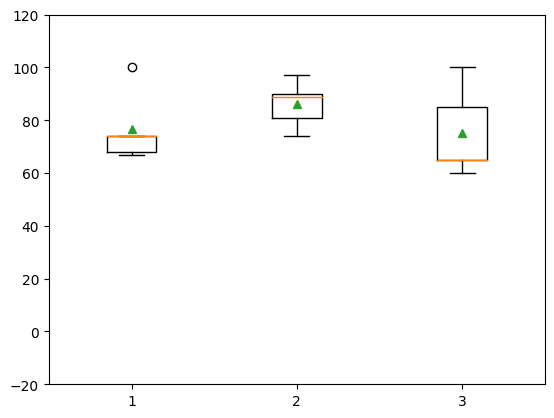

In [13]:
plt.boxplot(array2, showmeans=True)
plt.ylim([-20, 120])
plt.show()

> **说明**：箱线图中的小圆圈用来表示离群点，也就是大于 $\small{Q_3 + 1.5 \times IQR}$ 或小于 $\small{Q_1 - 1.5 \times IQR}$ 的值。公式中的常量 1.5 可以通过绘制箱线图的`boxplot`函数的`whis`参数进行修改，常用的值是 1.5 和 3，修改为 3 通常是为了标识出极度离群点。

需要说明的是，NumPy 的数组对象并没有提供计算几何平均值、调和平均值、去尾平均值等的方法，如果有这方面的需求，可以使用名为 scipy 的三方库，它的`stats`模块中提供了这些函数。此外，该模块还提供了计算众数、变异系数、偏态、峰度的函数，代码如下所示。

代码：

In [14]:
from scipy import stats

print(np.mean(array1))                # 算术平均值
print(stats.gmean(array1))            # 几何平均值
print(stats.hmean(array1))            # 调和平均值
print(stats.tmean(array1, [10, 90]))  # 去尾平均值
print(stats.variation(array1))        # 变异系数
print(stats.skew(array1))             # 偏态系数
print(stats.kurtosis(array1))         # 峰度系数

44.4
32.33283532651338
21.475151783809885
43.25
0.6861204718140852
0.3583347258711927
-1.4049948217064467


#### 其他相关方法概述

1. `all()` / `any()`方法：判断数组是否所有元素都是`True` / 判断数组是否有为`True`的元素。

2. `astype()`方法：拷贝数组，并将数组中的元素转换为指定的类型。

3. `reshape()`方法：调整数组对象的形状。

4. `dump()`方法：保存数组到二进制文件中，可以通过 NumPy 中的`load()`函数从保存的文件中加载数据创建数组。

    代码：

In [17]:
array1.dump('array1-data')
array3 = np.load('array1-data', allow_pickle=True)
array3

array([84, 28, 92, 28, 17, 82, 56,  6, 11, 40])

5. `tofile()`方法：将数组对象写入文件中。

In [ ]:
array1.tofile('array.txt', sep=',')

6. `fill()`方法：向数组中填充指定的元素。

7. `flatten()`方法：将多维数组扁平化为一维数组。

    代码：

In [ ]:
array2.flatten()

8. `nonzero()`方法：返回非0元素的索引。

9. `round()`方法：对数组中的元素做四舍五入操作。

10. `sort()`方法：对数组进行就地排序。

    代码：

In [ ]:
array1.sort()
array1

11. `swapaxes()`和`transpose()`方法：交换数组指定的轴和转置。

    代码：

In [ ]:
array2.swapaxes(0, 1)

    代码：

In [ ]:
array2.transpose()

array([[ 67,  74,  68, 100,  74],
       [ 97,  74,  90,  89,  81],
       [ 60,  85,  65,  65, 100]])

12. `tolist()`方法：将数组转成 Python 中的`list`。

    代码：

In [ ]:
print(array2.tolist())
print(type(array2.tolist()))